### Cell 1: Import thư viện và Tải tài nguyên NLTK

In [1]:
import os
import re
import string
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import LinearSVC

from wordcloud import WordCloud

from IPython.display import display

# Cấu hình đồ họa
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

# Tắt cảnh báo không cần thiết để báo cáo sạch hơn
warnings.filterwarnings('ignore')

# Khai báo các hằng số (Constants) dùng chung cho toàn dự án
RANDOM_STATE = 42
MAX_TFIDF_FEATURES = 5000

# Download NLTK data (Chỉ cần chạy 1 lần)
# nltk.download('stopwords')
# nltk.download('wordnet')
# nltk.download('omw-1.4')

### Cell 2: Khởi tạo các hàm Tiền xử lý dữ liệu (Preprocessing)

In [2]:
# Khởi tạo Lemmatizer và Stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
political_stopwords = {'said', 'also', 'would', 'could', 'told', 'reuters', 'washington', 'statement', 'press'}
stop_words.update(political_stopwords)

def deep_clean_text(text):
    """Làm sạch thô văn bản văn bản: xóa header Reuters, URL, HTML, dấu câu, kí tự rác"""
    text = str(text)
    # 1. Xử lý Header nguồn tin & địa danh
    text = re.sub(r'^.*?\\(reuters\\)\\s*[-–—]\\s*', '', text, flags=re.IGNORECASE)
    text = re.sub(r'^.*?\\s?[-–—]\\s?', '', text, count=1)
    
    # 2. Chuẩn hóa & Xóa rác web
    text = text.lower()
    text = re.sub(r'https?://\\S+|www\\.\\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    
    # 3. Xóa dấu câu & khoảng trắng thừa
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\\n', ' ', text)
    text = re.sub(r'\\s+', ' ', text).strip()
    return text

def lemmatize_and_remove_stopwords(text):
    """Chuẩn hóa ngôn ngữ bằng cách tách từ, xóa stopwords và Lemmatization"""
    words = str(text).split()
    clean_words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return " ".join(clean_words)

### Cell 3: Đọc, Làm sạch và Chuẩn hóa Dữ liệu

In [3]:
# 1. Đọc dữ liệu thô
df_fake = pd.read_csv('../data/raw/Fake.csv')
df_true = pd.read_csv('../data/raw/True.csv')

# 2. Gán nhãn và Gộp bài báo
df_fake['label'] = 1
df_true['label'] = 0
df = pd.concat([df_fake, df_true], axis=0).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

# 3. Loại bỏ cột không cần thiết và hàng trùng lặp/thiếu
df.drop(columns=['subject', 'date'], inplace=True, errors='ignore')
df = df.drop_duplicates(subset=['text']).dropna().reset_index(drop=True)
df = df[df['text'].str.strip() != ""].reset_index(drop=True)

# 4. Làm sạch sâu văn bản thô
df['text_clean_raw'] = df['text'].apply(deep_clean_text)
df['title_clean_raw'] = df['title'].apply(deep_clean_text)

# 5. Tạo 2 phiên bản dữ liệu nền tảng chưa Lemmatize (để đếm ký tự hoa/dấu câu chính xác)
df['text_only_base'] = df['text_clean_raw']
df['title_text_base'] = df['title_clean_raw'] + " " + df['text_clean_raw']
df['title_only_base'] = df['title_clean_raw']

# 6. Thực hiện Lemmatization cho bước Vector hóa
df['text_only_clean'] = df['text_only_base'].apply(lemmatize_and_remove_stopwords)
df['title_text_clean'] = df['title_text_base'].apply(lemmatize_and_remove_stopwords)
df['title_only_clean'] = df['title_only_base'].apply(lemmatize_and_remove_stopwords)

# Xóa các bài bị trùng nhau sau khi đã gọt bỏ dấu câu/stopwords/reuters
df = df.drop_duplicates(subset=['text_only_clean']).reset_index(drop=True) # type: ignore

# (Tùy chọn an toàn): Xóa các bài mà sau khi clean bị rỗng (do bài gốc chỉ toàn stop-words hoặc link)
df = df[df['text_only_clean'].str.strip() != ""].reset_index(drop=True)

# 7. Lưu file đã xử lý
output_path = '../data/processed/processed_data.csv'
os.makedirs(os.path.dirname(output_path), exist_ok=True)
df.to_csv(output_path, index=False, encoding='utf-8')
print(f"Đã xử lý xong dữ liệu và lưu tại: {output_path}")

Đã xử lý xong dữ liệu và lưu tại: ../data/processed/processed_data.csv


### Cell 4: Phân tích Khám phá Dữ liệu (EDA)

=== THỐNG KÊ MẪU DỮ LIỆU ===
Tổng số mẫu: 38634 | Số đặc trưng: 11
Tin thật (0): 21188 (54.84%) | Tin giả (1): 17446 (45.16%)


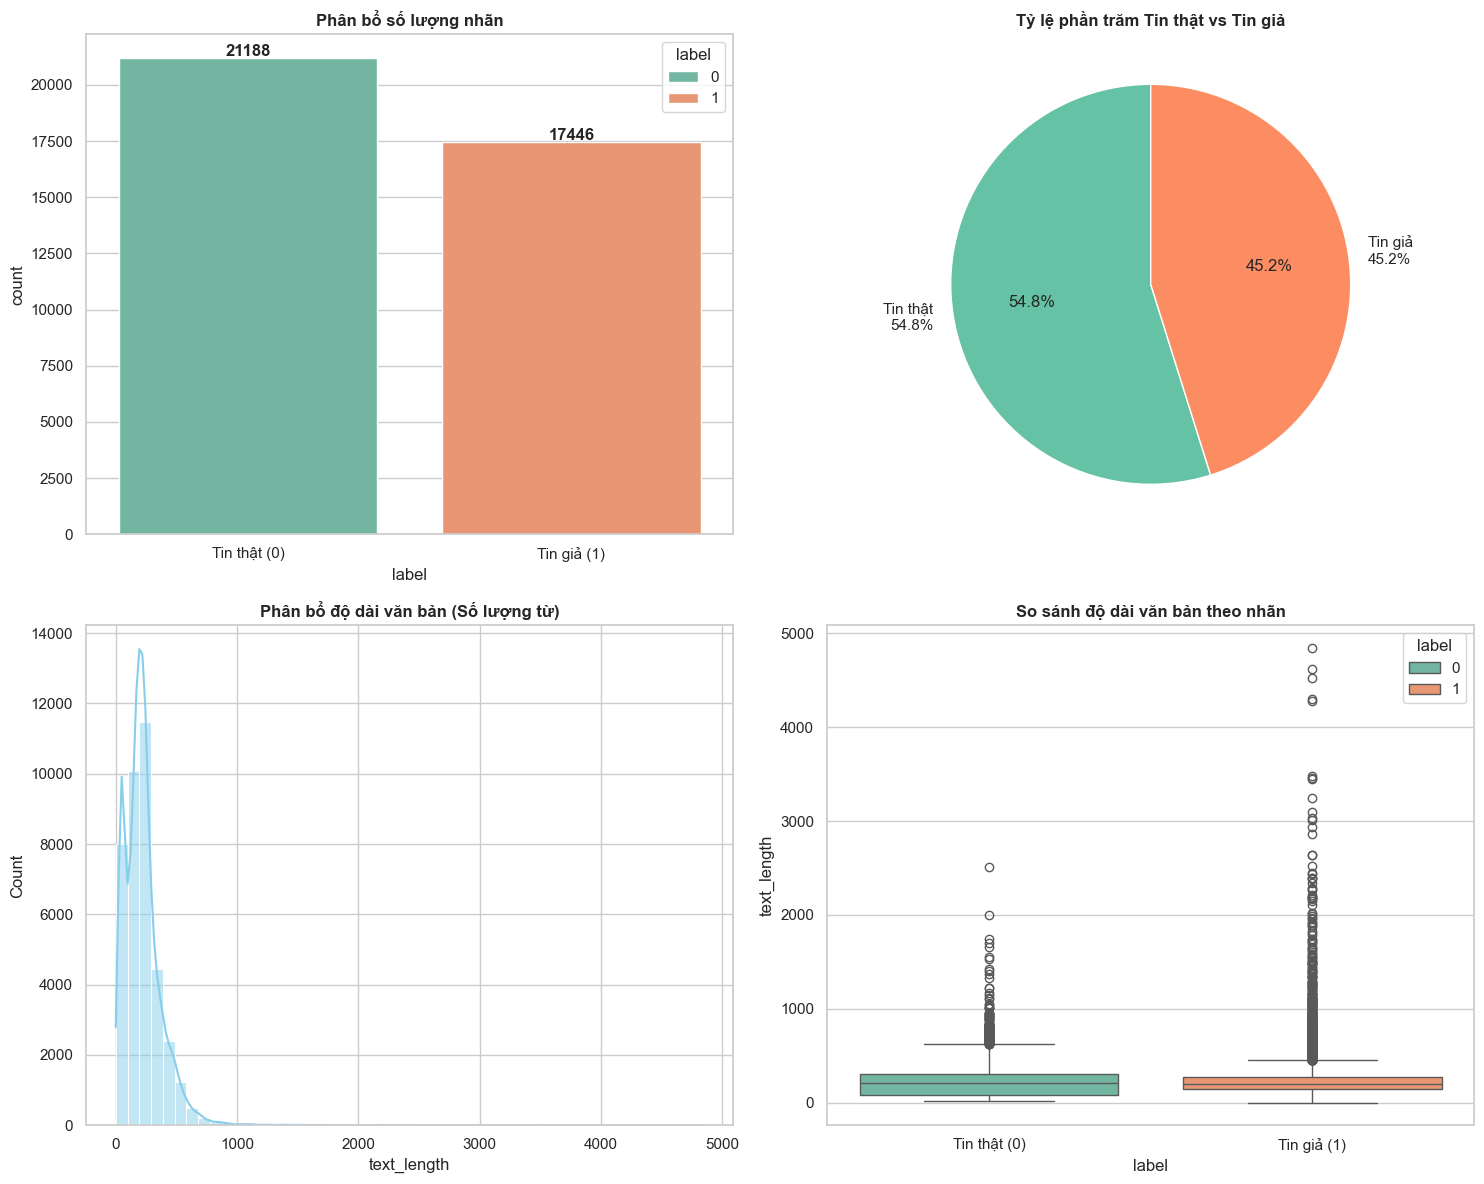

In [4]:
num_samples, num_features = df.shape
label_counts = df['label'].value_counts()
true_count, fake_count = label_counts[0], label_counts[1]

print(f"=== THỐNG KÊ MẪU DỮ LIỆU ===\nTổng số mẫu: {num_samples} | Số đặc trưng: {num_features}")
print(f"Tin thật (0): {true_count} ({true_count/num_samples*100:.2f}%) | Tin giả (1): {fake_count} ({fake_count/num_samples*100:.2f}%)")

# Tạo trường độ dài văn bản để trực quan hóa
df['text_length'] = df['text_only_clean'].apply(lambda x: len(str(x).split()))

# Vẽ đồ thị 2x2
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Subplot 1: Countplot
sns.countplot(x='label', hue='label', data=df, palette='Set2', ax=axes[0, 0])
axes[0, 0].set_title('Phân bổ số lượng nhãn', fontweight='bold')
axes[0, 0].set_xticklabels(['Tin thật (0)', 'Tin giả (1)'])
for i, v in enumerate([true_count, fake_count]):
    axes[0, 0].text(i, v + 100, str(v), ha='center', fontweight='bold')

# Subplot 2: Pie chart
axes[0, 1].pie([true_count, fake_count], labels=[f'Tin thật\n{true_count/num_samples*100:.1f}%', f'Tin giả\n{fake_count/num_samples*100:.1f}%'], colors=['#66c2a5', '#fc8d62'], autopct='%1.1f%%', startangle=90)
axes[0, 1].set_title('Tỷ lệ phần trăm Tin thật vs Tin giả', fontweight='bold')

# Subplot 3: Phân bổ độ dài từ
sns.histplot(df['text_length'], bins=50, kde=True, color='skyblue', ax=axes[1, 0])
axes[1, 0].set_title('Phân bổ độ dài văn bản (Số lượng từ)', fontweight='bold')

# Subplot 4: Boxplot độ dài theo nhãn
sns.boxplot(x='label', y='text_length', hue='label', data=df, palette='Set2', ax=axes[1, 1])
axes[1, 1].set_title('So sánh độ dài văn bản theo nhãn', fontweight='bold')
axes[1, 1].set_xticklabels(['Tin thật (0)', 'Tin giả (1)'])

plt.tight_layout()
plt.show()

### Cell 5: Phân tách Tập dữ liệu & Kỹ nghệ Đặc trưng (Feature Engineering Pipeline)

In [5]:
# Phân tách tập Train / Test đồng đều theo nhãn (Stratify)
train_idx, test_idx = train_test_split(df.index, test_size=0.2, random_state=RANDOM_STATE, stratify=df['label'])
y_train = df.loc[train_idx, 'label']
y_test = df.loc[test_idx, 'label']

print("Đang kiểm tra rò rỉ dữ liệu (trùng lặp) giữa tập Train và Test...")

# Lấy tập hợp các văn bản đã làm sạch ở kịch bản Text Only
train_texts_set = set(df.loc[train_idx, 'text_only_clean'])
test_texts_set = set(df.loc[test_idx, 'text_only_clean'])

# Tìm phần giao nhau (trùng lặp)
exact_overlap = train_texts_set.intersection(test_texts_set)

print(f"-> Số lượng bài báo trùng lặp hoàn toàn giữa Train và Test: {len(exact_overlap)}")
if len(exact_overlap) == 0:
    print("-> Tuyệt vời! Không có hiện tượng học vẹt do trùng lặp dữ liệu.")
else:
    print("-> CẢNH BÁO: Cần xem lại bước df.drop_duplicates() ở phần làm sạch dữ liệu!")
print("="*69 + "\n")

def extract_meta_features(text_series):
    """Tính toán các đặc trưng thủ công (Độ dài bài viết, Tỷ lệ viết hoa, Tỷ lệ dấu câu)"""
    def count_punct(text):
        words = str(text).split()
        if not words: return 0
        punct_count = sum(1 for char in text if char in string.punctuation)
        return (punct_count / len(words)) * 100

    def count_caps(text):
        words = str(text).split()
        if not words: return 0
        cap_count = sum(1 for char in text if char.isupper())
        return (cap_count / len(words)) * 100

    lengths = text_series.apply(lambda x: len(str(x).split())).values.reshape(-1, 1)
    puncts = text_series.apply(count_punct).values.reshape(-1, 1)
    caps = text_series.apply(count_caps).values.reshape(-1, 1)
    
    return np.hstack([lengths, puncts, caps])

def build_feature_pipeline(clean_col, base_col):
    """Pipeline xây dựng ma trận đặc trưng kết hợp TF-IDF và Meta Features hoàn chỉnh"""
    # 1. Trích xuất văn bản tương ứng
    X_train_clean = df.loc[train_idx, clean_col]
    X_test_clean = df.loc[test_idx, clean_col]
    X_train_base = df.loc[train_idx, base_col]
    X_test_base = df.loc[test_idx, base_col]
    
    # 2. Vector hóa TF-IDF bằng dữ liệu đã chuẩn hóa (clean)
    tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=MAX_TFIDF_FEATURES, stop_words='english')
    X_train_tfidf = tfidf.fit_transform(X_train_clean).toarray()
    X_test_tfidf = tfidf.transform(X_test_clean).toarray()
    
    # 3. Tính toán Meta Features từ dữ liệu nền tảng gốc (base) để không mất thông tin hoa/dấu câu
    train_meta = extract_meta_features(X_train_base)
    test_meta = extract_meta_features(X_test_base)
    
    # 4. Ghép mảng đặc trưng
    X_train_full = np.hstack([X_train_tfidf, train_meta])
    X_test_full = np.hstack([X_test_tfidf, test_meta])
    
    # 5. Chuẩn hóa tỷ lệ (MinMax Scaling)
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train_full)
    X_test_scaled = scaler.transform(X_test_full)
    
    return X_train_scaled, X_test_scaled, tfidf

# Tiến hành tạo tập dữ liệu cho 2 kịch bản thử nghiệm
print("Đang trích xuất đặc trưng cho kịch bản 'Text Only'...")
X_train_text, X_test_text, tfidf_text = build_feature_pipeline('text_only_clean', 'text_only_base')

print("Đang trích xuất đặc trưng cho kịch bản 'Title + Text'...")
X_train_title, X_test_title, tfidf_title = build_feature_pipeline('title_text_clean', 'title_text_base')

print("Đang trích xuất đặc trưng cho kịch bản 'Title Only'...")
X_train_title_only, X_test_title_only, tfidf_title_only = build_feature_pipeline('title_only_clean', 'title_only_base')

Đang kiểm tra rò rỉ dữ liệu (trùng lặp) giữa tập Train và Test...
-> Số lượng bài báo trùng lặp hoàn toàn giữa Train và Test: 0
-> Tuyệt vời! Không có hiện tượng học vẹt do trùng lặp dữ liệu.

Đang trích xuất đặc trưng cho kịch bản 'Text Only'...
Đang trích xuất đặc trưng cho kịch bản 'Title + Text'...
Đang trích xuất đặc trưng cho kịch bản 'Title Only'...


### Cell 6: Hàm Huấn luyện và Đánh giá Mô hình đa dụng

In [6]:
def train_and_evaluate_model(model, model_name, X_train, X_test, cmap="Blues"):
    """Hàm huấn luyện mô hình chung giúp tối giản hóa mã nguồn"""
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    
    # Vẽ Confusion Matrix trực quan
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 3.5))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=['Dự đoán 0', 'Dự đoán 1'],
                yticklabels=['Thực tế 0', 'Thực tế 1'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('Thực tế')
    plt.xlabel('Dự đoán')
    plt.show()
    
    return acc, report

def display_comparison_report(model_name, acc_title_text, report_title_text, acc_text_only, report_text_only, acc_title_only, report_title_only):
    """In bảng so sánh chi tiết kết quả chạy thực nghiệm cho 3 kịch bản"""
    print("=" * 95)
    print(f"{f'SO SÁNH MÔ HÌNH: {model_name}':^95}")
    print("=" * 95)
    
    # Cập nhật thêm cột Title Only
    print(f"{'Chỉ số (Metric)':<25} {'Title + Text':>20} {'Text Only':>20} {'Title Only':>20}")
    print("-" * 95)
    
    for cls, name in [('0', 'Tin thật'), ('1', 'Tin giả')]:
        print(f"{f'{name} Precision':<25} {report_title_text[cls]['precision']:>20.3f} {report_text_only[cls]['precision']:>20.3f} {report_title_only[cls]['precision']:>20.3f}")
        print(f"{f'{name} Recall':<25} {report_title_text[cls]['recall']:>20.3f} {report_text_only[cls]['recall']:>20.3f} {report_title_only[cls]['recall']:>20.3f}")
        print(f"{f'{name} F1-score':<25} {report_title_text[cls]['f1-score']:>20.3f} {report_text_only[cls]['f1-score']:>20.3f} {report_title_only[cls]['f1-score']:>20.3f}")
        print("-" * 95)
        
    print(f"{'Độ chính xác (Accuracy)':<25} {acc_title_text:>20.3f} {acc_text_only:>20.3f} {acc_title_only:>20.3f}\n")

### Cell 7: Thực nghiệm 1 - Logistic Regression

--- HUẤN LUYỆN LOGISTIC REGRESSION ---


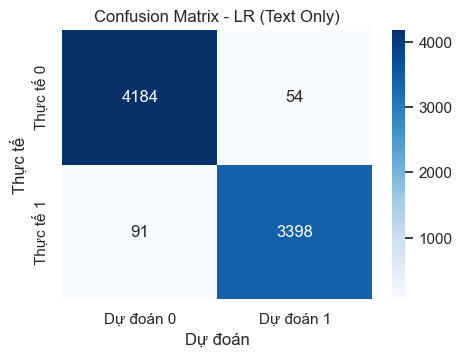

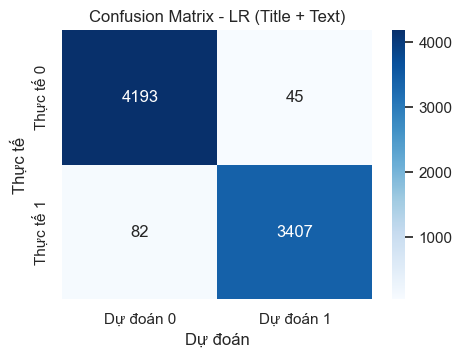

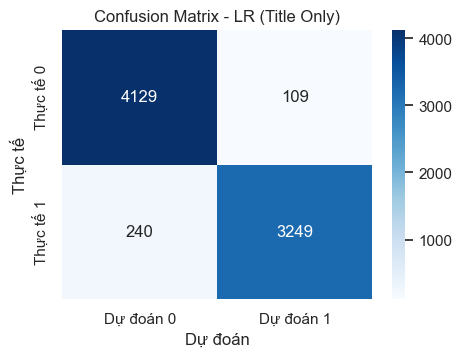

                             SO SÁNH MÔ HÌNH: LOGISTIC REGRESSION                              
Chỉ số (Metric)                   Title + Text            Text Only           Title Only
-----------------------------------------------------------------------------------------------
Tin thật Precision                       0.981                0.979                0.945
Tin thật Recall                          0.989                0.987                0.974
Tin thật F1-score                        0.985                0.983                0.959
-----------------------------------------------------------------------------------------------
Tin giả Precision                        0.987                0.984                0.968
Tin giả Recall                           0.976                0.974                0.931
Tin giả F1-score                         0.982                0.979                0.949
-----------------------------------------------------------------------------------------

In [7]:
print("--- HUẤN LUYỆN LOGISTIC REGRESSION ---")
lr_model = LogisticRegression(max_iter=1000)

acc_lr_text, rep_lr_text = train_and_evaluate_model(lr_model, "LR (Text Only)", X_train_text, X_test_text, "Blues")
acc_lr_title, rep_lr_title = train_and_evaluate_model(lr_model, "LR (Title + Text)", X_train_title, X_test_title, "Blues")
acc_lr_title_only, rep_lr_title_only = train_and_evaluate_model(lr_model, "LR (Title Only)", X_train_title_only, X_test_title_only, "Blues")

display_comparison_report("LOGISTIC REGRESSION", acc_lr_title, rep_lr_title, acc_lr_text, rep_lr_text, acc_lr_title_only, rep_lr_title_only)

### Cell 8: Thực nghiệm 2 - Naive Bayes

--- HUẤN LUYỆN NAIVE BAYES ---


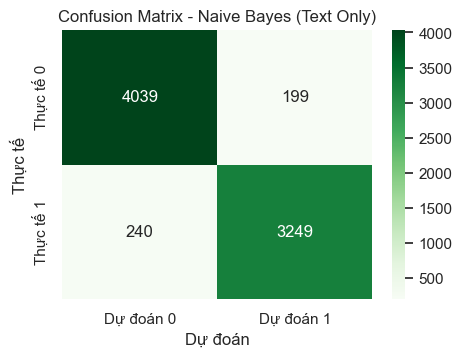

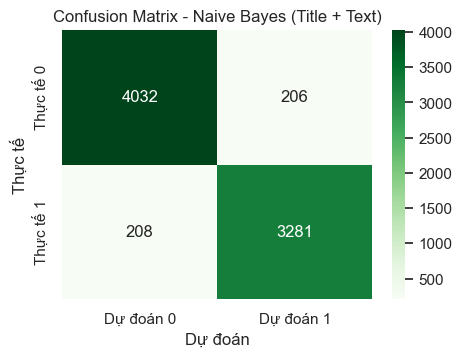

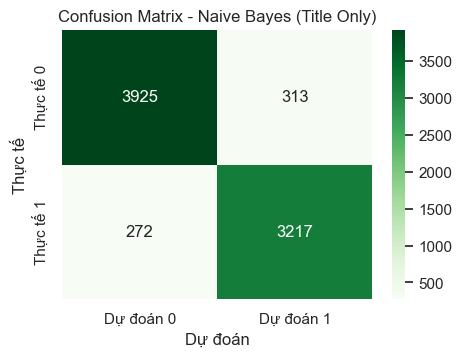

                                 SO SÁNH MÔ HÌNH: NAIVE BAYES                                  
Chỉ số (Metric)                   Title + Text            Text Only           Title Only
-----------------------------------------------------------------------------------------------
Tin thật Precision                       0.951                0.944                0.935
Tin thật Recall                          0.951                0.953                0.926
Tin thật F1-score                        0.951                0.948                0.931
-----------------------------------------------------------------------------------------------
Tin giả Precision                        0.941                0.942                0.911
Tin giả Recall                           0.940                0.931                0.922
Tin giả F1-score                         0.941                0.937                0.917
-----------------------------------------------------------------------------------------

In [8]:
print("--- HUẤN LUYỆN NAIVE BAYES ---")
nb_model = MultinomialNB()

acc_nb_text, rep_nb_text = train_and_evaluate_model(nb_model, "Naive Bayes (Text Only)", X_train_text, X_test_text, "Greens")
acc_nb_title, rep_nb_title = train_and_evaluate_model(nb_model, "Naive Bayes (Title + Text)", X_train_title, X_test_title, "Greens")
acc_nb_title_only, rep_nb_title_only = train_and_evaluate_model(nb_model, "Naive Bayes (Title Only)", X_train_title_only, X_test_title_only, "Greens")

display_comparison_report("NAIVE BAYES", acc_nb_title, rep_nb_title, acc_nb_text, rep_nb_text, acc_nb_title_only, rep_nb_title_only)

### Cell 9: Thực nghiệm 3 - SVM (Linear Support Vector Classifier)

--- HUẤN LUYỆN SVM ---


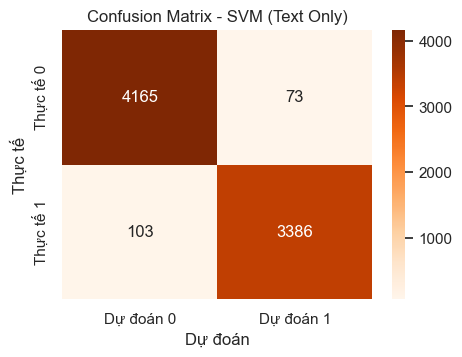

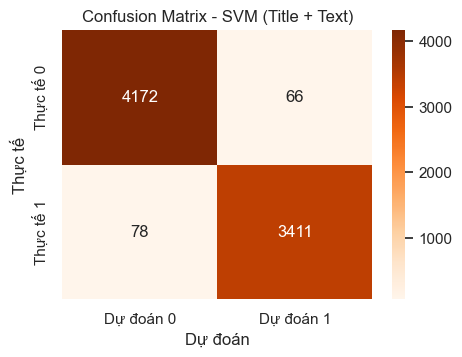

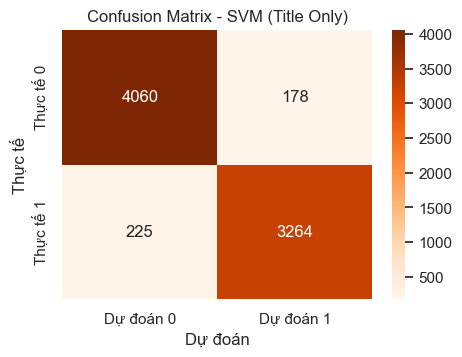

                                     SO SÁNH MÔ HÌNH: SVM                                      
Chỉ số (Metric)                   Title + Text            Text Only           Title Only
-----------------------------------------------------------------------------------------------
Tin thật Precision                       0.982                0.976                0.947
Tin thật Recall                          0.984                0.983                0.958
Tin thật F1-score                        0.983                0.979                0.953
-----------------------------------------------------------------------------------------------
Tin giả Precision                        0.981                0.979                0.948
Tin giả Recall                           0.978                0.970                0.936
Tin giả F1-score                         0.979                0.975                0.942
-----------------------------------------------------------------------------------------

In [9]:
print("--- HUẤN LUYỆN SVM ---")
svm_model = LinearSVC(random_state=RANDOM_STATE, max_iter=2000)

acc_svm_text, rep_svm_text = train_and_evaluate_model(svm_model, "SVM (Text Only)", X_train_text, X_test_text, "Oranges")
acc_svm_title, rep_svm_title = train_and_evaluate_model(svm_model, "SVM (Title + Text)", X_train_title, X_test_title, "Oranges")
acc_svm_title_only, rep_svm_title_only = train_and_evaluate_model(svm_model, "SVM (Title Only)", X_train_title_only, X_test_title_only, "Oranges")

display_comparison_report("SVM", acc_svm_title, rep_svm_title, acc_svm_text, rep_svm_text, acc_svm_title_only, rep_svm_title_only)

### Cell 10: Phân tích top features

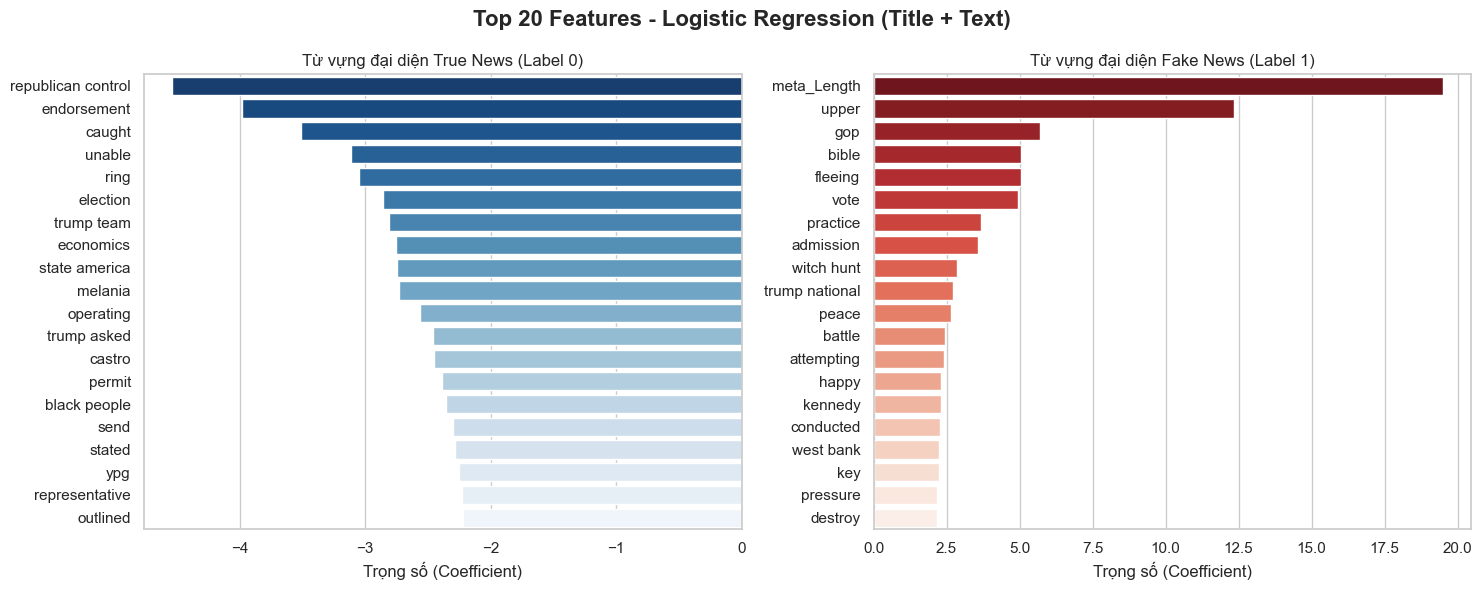

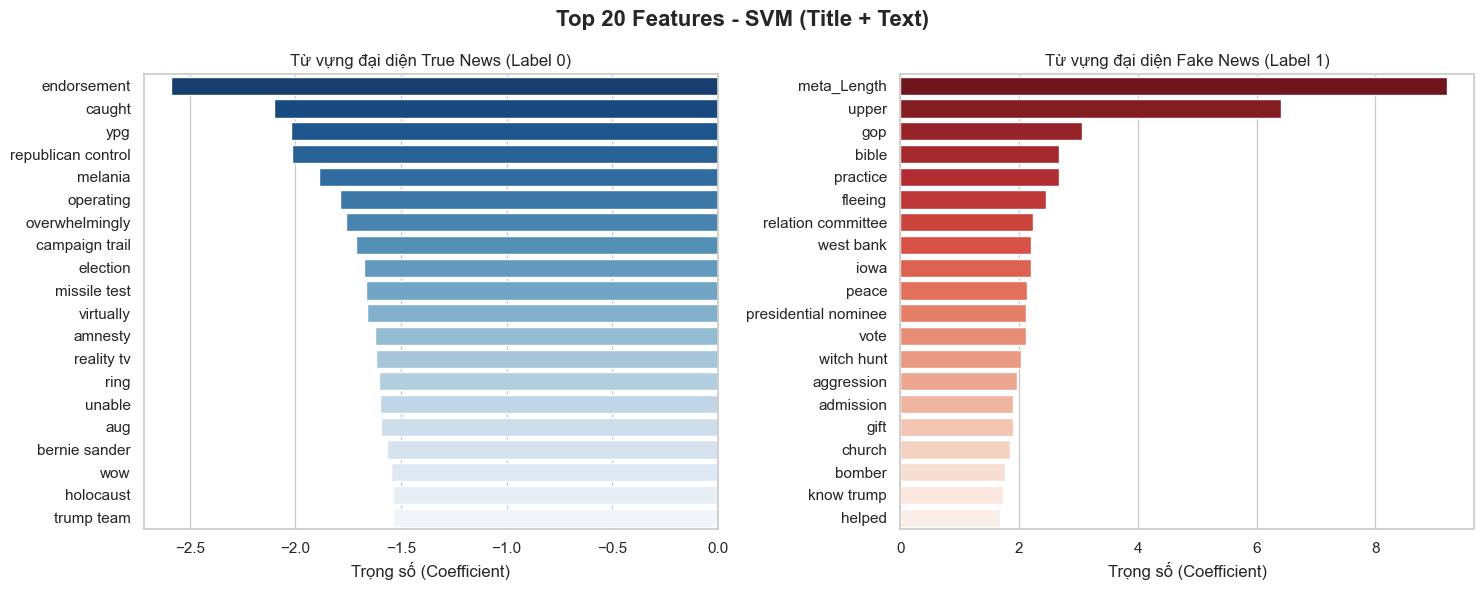

In [10]:
def plot_top_features(vectorizer, model, model_name, top_n=20):
    """
    Hàm vẽ biểu đồ Top Features có hỗ trợ Meta Features
    """
    # 1. Lấy danh sách từ vựng từ TF-IDF
    feature_names = list(vectorizer.get_feature_names_out())
    
    # 2. Thêm thủ công 3 tên Meta Features cho khớp với ma trận np.hstack của bạn
    feature_names.extend(['meta_Length', 'meta_Punctuation', 'meta_Capitals'])
    
    # 3. Lấy trọng số của mô hình
    coefs = model.coef_[0]
    
    # 4. Kiểm tra an toàn độ dài
    if len(feature_names) != len(coefs):
        print(f"Lỗi: Số lượng features ({len(feature_names)}) không khớp với số lượng weights ({len(coefs)}).")
        return
        
    # 5. Ghép từ vựng và trọng số
    features_with_coefs = list(zip(feature_names, coefs))
    
    # 6. Sắp xếp
    top_true_features = sorted(features_with_coefs, key=lambda x: x[1])[:top_n]
    top_fake_features = sorted(features_with_coefs, key=lambda x: x[1], reverse=True)[:top_n]
    
    # Tách dữ liệu để vẽ
    true_words, true_scores = zip(*top_true_features)
    fake_words, fake_scores = zip(*top_fake_features)
    
    # Trực quan hóa
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle(f'Top {top_n} Features - {model_name}', fontsize=16, fontweight='bold')
    
    sns.barplot(x=list(true_scores), y=list(true_words), ax=axes[0], palette='Blues_r')
    axes[0].set_title('Từ vựng đại diện True News (Label 0)')
    axes[0].set_xlabel('Trọng số (Coefficient)')
    
    sns.barplot(x=list(fake_scores), y=list(fake_words), ax=axes[1], palette='Reds_r')
    axes[1].set_title('Từ vựng đại diện Fake News (Label 1)')
    axes[1].set_xlabel('Trọng số (Coefficient)')
    
    plt.tight_layout()
    plt.show()

# Đảm bảo bạn gọi đoạn này SAU KHI đã huấn luyện xong lr_model và svm_model
plot_top_features(tfidf_title, lr_model, "Logistic Regression (Title + Text)")
plot_top_features(tfidf_title, svm_model, "SVM (Title + Text)")

### Cell 11: Tổng hợp kết quả toàn bộ thử nghiệm

In [11]:
import pandas as pd

def extract_macro_metrics(acc, report):
    """
    Hàm phụ trợ trích xuất chỉ số trung bình (macro avg) từ classification_report
    """
    return {
        "Accuracy": f"{acc:.4f}",
        "Precision": f"{report['macro avg']['precision']:.4f}",
        "Recall": f"{report['macro avg']['recall']:.4f}",
        "F1-score": f"{report['macro avg']['f1-score']:.4f}"
    }

# Lấy dữ liệu cho từng cấu hình
data = []

# --- 1. LOGISTIC REGRESSION ---
lr_text = extract_macro_metrics(acc_lr_text, rep_lr_text)
data.append(["Logistic Regression", "Text Only", lr_text['Accuracy'], lr_text['Precision'], lr_text['Recall'], lr_text['F1-score']])

lr_title_text = extract_macro_metrics(acc_lr_title, rep_lr_title)
data.append(["Logistic Regression", "Title + Text", lr_title_text['Accuracy'], lr_title_text['Precision'], lr_title_text['Recall'], lr_title_text['F1-score']])

lr_title_only = extract_macro_metrics(acc_lr_title_only, rep_lr_title_only)
data.append(["Logistic Regression", "Title Only", lr_title_only['Accuracy'], lr_title_only['Precision'], lr_title_only['Recall'], lr_title_only['F1-score']])


# --- 2. NAIVE BAYES ---
# (Đảm bảo bạn đã huấn luyện và lưu các biến acc_nb_..., rep_nb_... tương tự như LR và SVM)
nb_text = extract_macro_metrics(acc_nb_text, rep_nb_text)
data.append(["Naive Bayes", "Text Only", nb_text['Accuracy'], nb_text['Precision'], nb_text['Recall'], nb_text['F1-score']])

nb_title_text = extract_macro_metrics(acc_nb_title, rep_nb_title)
data.append(["Naive Bayes", "Title + Text", nb_title_text['Accuracy'], nb_title_text['Precision'], nb_title_text['Recall'], nb_title_text['F1-score']])

# Nếu bạn chưa làm kịch bản Title Only cho Naive Bayes, hãy huấn luyện nó trước khi chạy dòng này
nb_title_only = extract_macro_metrics(acc_nb_title_only, rep_nb_title_only)
data.append(["Naive Bayes", "Title Only", nb_title_only['Accuracy'], nb_title_only['Precision'], nb_title_only['Recall'], nb_title_only['F1-score']])


# --- 3. SVM ---
svm_text = extract_macro_metrics(acc_svm_text, rep_svm_text)
data.append(["SVM", "Text Only", svm_text['Accuracy'], svm_text['Precision'], svm_text['Recall'], svm_text['F1-score']])

svm_title_text = extract_macro_metrics(acc_svm_title, rep_svm_title)
data.append(["SVM", "Title + Text", svm_title_text['Accuracy'], svm_title_text['Precision'], svm_title_text['Recall'], svm_title_text['F1-score']])

svm_title_only = extract_macro_metrics(acc_svm_title_only, rep_svm_title_only)
data.append(["SVM", "Title Only", svm_title_only['Accuracy'], svm_title_only['Precision'], svm_title_only['Recall'], svm_title_only['F1-score']])

# Tạo DataFrame
columns = ["Mô hình", "Dữ liệu", "Accuracy", "Precision", "Recall", "F1-score"]
summary_df = pd.DataFrame(data, columns=columns)

# In bảng ra màn hình
print("=" * 80)
print(f"{'BẢNG TỔNG HỢP METRICS CÁC MÔ HÌNH VÀ KỊCH BẢN DỮ LIỆU':^80}")
print("=" * 80)
print(summary_df.to_string(index=False, justify='center'))

# (Tùy chọn) Lưu ra file CSV để dán vào báo cáo Word cho dễ
summary_df.to_csv('../data/processed/model_metrics_summary.csv', index=False)

             BẢNG TỔNG HỢP METRICS CÁC MÔ HÌNH VÀ KỊCH BẢN DỮ LIỆU              
      Mô hình         Dữ liệu    Accuracy Precision Recall F1-score
Logistic Regression    Text Only  0.9812    0.9815  0.9806  0.9810 
Logistic Regression Title + Text  0.9836    0.9839  0.9829  0.9834 
Logistic Regression   Title Only  0.9548    0.9563  0.9527  0.9542 
        Naive Bayes    Text Only  0.9432    0.9431  0.9421  0.9426 
        Naive Bayes Title + Text  0.9464    0.9459  0.9459  0.9459 
        Naive Bayes   Title Only  0.9243    0.9233  0.9241  0.9237 
                SVM    Text Only  0.9772    0.9774  0.9766  0.9770 
                SVM Title + Text  0.9814    0.9813  0.9810  0.9812 
                SVM   Title Only  0.9478    0.9479  0.9468  0.9473 


### Cell 12: WordCloud

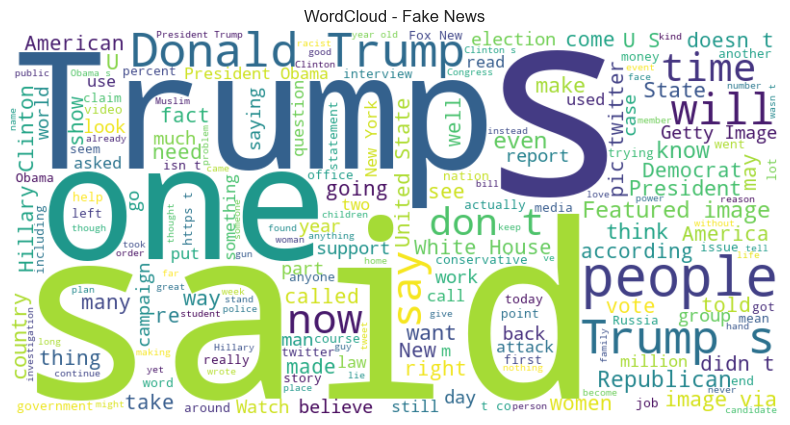

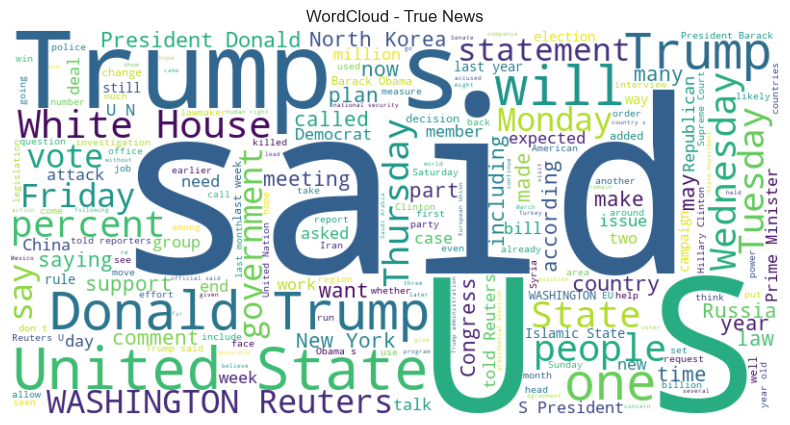

In [12]:
fake_text = " ".join(df[df['label'] == 1]['text'])
true_text = " ".join(df[df['label'] == 0]['text'])

# WordCloud Fake News
wc_fake = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(fake_text)

plt.figure(figsize=(10,5))
plt.imshow(wc_fake, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud - Fake News")
plt.show()

# WordCloud True News
wc_true = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(true_text)

plt.figure(figsize=(10,5))
plt.imshow(wc_true, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud - True News")
plt.show()

### Cell 13: Phân tích mẫu dự đoán sai

In [13]:
print("Đang tiến hành trích xuất các mẫu dự đoán sai...")

# 1. Dự đoán lại trên tập Test bằng mô hình tốt nhất (Ví dụ: Logistic Regression với kịch bản Title + Text)
y_pred_analysis = lr_model.predict(X_test_title)

# 2. Tạo DataFrame chứa thông tin để đối chiếu
error_analysis_df = pd.DataFrame({
    'Tiêu đề gốc (Title)': df.loc[test_idx, 'title'],
    'Nội dung gốc (Text)': df.loc[test_idx, 'text'],
    'Thực tế (True Label)': y_test,
    'Dự đoán (Predicted)': y_pred_analysis
})

# 3. Lọc ra các dòng dự đoán sai
errors = error_analysis_df[error_analysis_df['Thực tế (True Label)'] != error_analysis_df['Dự đoán (Predicted)']]

# 4. Tách thành 2 nhóm lỗi
# False Positives (FP): Thực tế là Tin Thật (0) nhưng bị model đoán nhầm là Tin Giả (1)
false_positives = errors[(errors['Thực tế (True Label)'] == 0) & (errors['Dự đoán (Predicted)'] == 1)]

# False Negatives (FN): Thực tế là Tin Giả (1) nhưng bị model đoán nhầm là Tin Thật (0)
false_negatives = errors[(errors['Thực tế (True Label)'] == 1) & (errors['Dự đoán (Predicted)'] == 0)]

print(f"Tổng số mẫu dự đoán sai: {len(errors)}")
print(f" - Số mẫu False Positives (Thật bị đoán là Giả): {len(false_positives)}")
print(f" - Số mẫu False Negatives (Giả bị đoán là Thật): {len(false_negatives)}\n")

# 5. Hiển thị 10 mẫu tiêu biểu cho mỗi loại
print("="*80)
print("📌 TOP 10 FALSE POSITIVES (Thực tế là TIN THẬT, bị đoán nhầm thành TIN GIẢ)")
print("="*80)
# Hiển thị bằng hàm display của IPython để bảng đẹp hơn trong Jupyter
display(false_positives.head(10))

print("\n" + "="*80)
print("📌 TOP 10 FALSE NEGATIVES (Thực tế là TIN GIẢ, bị đoán nhầm thành TIN THẬT)")
print("="*80)
display(false_negatives.head(10))

Đang tiến hành trích xuất các mẫu dự đoán sai...
Tổng số mẫu dự đoán sai: 3447
 - Số mẫu False Positives (Thật bị đoán là Giả): 55
 - Số mẫu False Negatives (Giả bị đoán là Thật): 3392

📌 TOP 10 FALSE POSITIVES (Thực tế là TIN THẬT, bị đoán nhầm thành TIN GIẢ)


,Tiêu đề gốc (Title),Nội dung gốc (Text),Thực tế (True Label),Dự đoán (Predicted)
17189,Russia to start registering some foreign media...,MOSCOW (Reuters) - Russia s justice ministry w...,0,1
275,Distrustful U.S. allies force spy agency to ba...,SAN FRANCISCO (Reuters) - An international gro...,0,1
28209,Trump picks conservative judge Gorsuch for Sup...,WASHINGTON (Reuters) - President Donald Trump ...,0,1
34796,Factbox: Trump fills top jobs for his administ...,(Reuters) - U.S. President-elect Donald Trump ...,0,1
26738,"Senate takes step toward passage of tax bill, ...",WASHINGTON (Reuters) - The U.S. Senate on Wedn...,0,1
6072,"Prankster, coughing fits mar Theresa May’s spe...","MANCHESTER, England (Reuters) - British Prime ...",0,1
28321,"Stung by criticism, Trump vows to work for eth...",WASHINGTON (Reuters) - U.S. Republican preside...,0,1
13769,Little hope of peace talks as renewed fighting...,KAMPALA (Reuters) - As fresh fighting looms in...,0,1
660,Factbox: Trump fills top jobs for his administ...,(Reuters) - U.S. President-elect Donald Trump ...,0,1
24149,Britain's 'thrilled' Prince Harry announces he...,LONDON (Reuters) - Britain s Prince Harry and ...,0,1



📌 TOP 10 FALSE NEGATIVES (Thực tế là TIN GIẢ, bị đoán nhầm thành TIN THẬT)


,Tiêu đề gốc (Title),Nội dung gốc (Text),Thực tế (True Label),Dự đoán (Predicted)
2946,BREAKING: Sworn Affidavit PROVES Clinton ‘Vic...,Donald Trump thought bringing Juanita Broaddri...,1,0
13734,CBS Reporter Describes Racism At Donald Trump...,CBS reporter Sopan Deb has been speaking out a...,1,0
5850,Senator Who Once Betrayed America To Iran Has...,Senator Tom Cotton just put on a legendary sho...,1,0
407,Colbert’s Merciless Mockery Of Oregon Militan...,The domestic terrorists currently occupying th...,1,0
2764,Former CIA/NSA Chief Says Trump’s Unlawful Or...,Donald Trump has this tough guy syndrome that ...,1,0
25764,NEW YORK KNOWN WOLF: Halloween Truck Attacker ...,Shawn Helton 21st Century WireYears before al...,1,0
16353,WATCH: Bernie Sanders SCORCHES Trump For Aban...,Donald Trump supporters who struggle to earn a...,1,0
34100,TREY GOWDY ON PETER STRZOK BIAS AGAINST TRUMP:...,Sunlight is the best disinfectant That s why w...,1,0
1262,WATCH: Fox News Host Furiously Directs Staff ...,"Apparently, Fox News hosts do not want their v...",1,0
1932,BREAKING: THE SUPREME COURT RULES AGAINST THE ...,SHOCKER! Great news that the EPA was shot down...,1,0
